## Replication of the PepMLM Model from the Nature Article

https://www.nature.com/articles/s41587-025-02761-2#data-availability

## Part 1: Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

DATA = "../data/"

complex_df   = pd.read_csv(DATA + "complex.csv")
train_df     = pd.read_csv(DATA + "pepnn_train_dataset.csv")
test_pep_df  = pd.read_csv(DATA + "pepnn_test_dataset.csv")
results_df   = pd.read_csv(DATA + "test.csv")

print("complex.csv         :", complex_df.shape)
print("pepnn_train_dataset :", train_df.shape)
print("pepnn_test_dataset  :", test_pep_df.shape)
print("test.csv (results)  :", results_df.shape)

complex.csv         : (19813, 30)
pepnn_train_dataset : (2828, 8)
pepnn_test_dataset  : (92, 7)
test.csv (results)  : (203, 9)


### 1.1 — Column Overview

In [3]:
for name, df in [("complex", complex_df), ("train", train_df), ("test_pep", test_pep_df), ("results", results_df)]:
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(df.dtypes.to_string())
    print(f"\nNull counts:\n{df.isnull().sum()[df.isnull().sum() > 0].to_string() or 'None'}")


  complex
PDB                                  str
Protein Name                         str
Resolution                       float64
Classification                       str
Peptide Chain                        str
Peptide Size                       int64
Peptide Sequence                     str
Peptide Description                  str
Peptide Organism                     str
Peptide Interface Area           float64
Peptide Molecular Weight             str
Peptide Aromaticity              float64
Peptide Instability                  str
Peptide Isoelectric Point        float64
Receptor Chain                       str
Receptor Size                      int64
Receptor Sequence                    str
Receptor Description                 str
Receptor Organism                    str
Receptor Interface Area          float64
Receptor Molecular Weight            str
Receptor Aromaticity             float64
Receptor Instability                 str
Receptor Isoelectric Point       float64
Seque

### 1.2 — Peptide Length Distributions

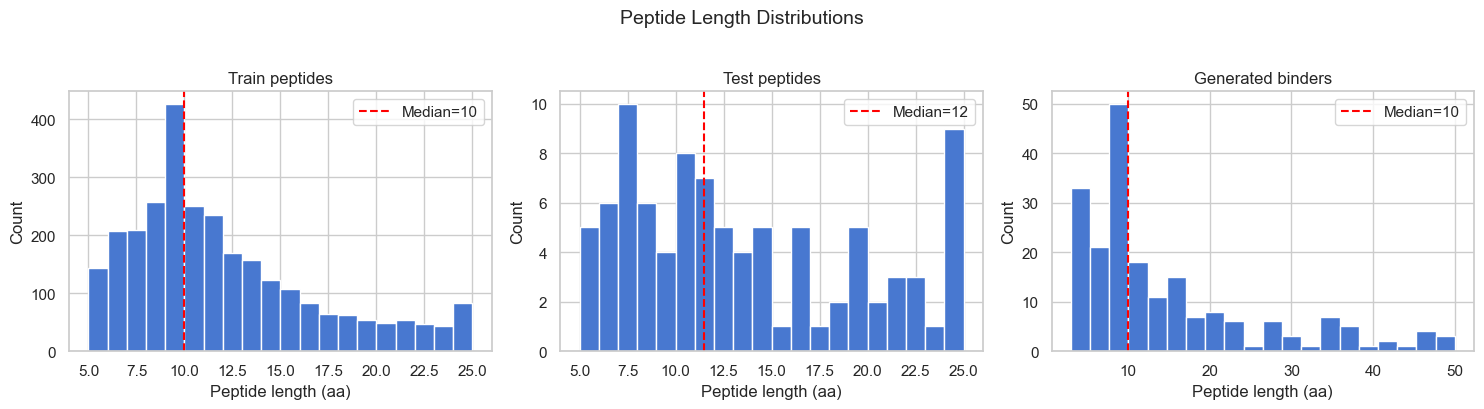

Train   — min/median/max: 5 10.0 25
Test    — min/median/max: 5 11.5 25
Results — min/median/max: 3 10.0 50


In [ ]:
train_df["pep_len"]    = train_df["Sequence"].str.len()
test_pep_df["pep_len"] = test_pep_df["Sequence"].str.len()
results_df["pep_len"]  = results_df["Binder"].str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (label, series) in zip(axes, [
    ("Train peptides",       train_df["pep_len"]),
    ("Test peptides",        test_pep_df["pep_len"]),
    ("Generated binders",    results_df["pep_len"]),
]):
    ax.hist(series.dropna(), bins=20, edgecolor="white")
    ax.set_title(label)
    ax.set_xlabel("Peptide length (aa)")
    ax.set_ylabel("Count")
    ax.axvline(series.median(), color="red", linestyle="--", label=f"Median={series.median():.0f}")
    ax.legend()

plt.suptitle("Peptide Length Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Train   — min/median/max:", train_df["pep_len"].min(), train_df["pep_len"].median(), train_df["pep_len"].max())
print("Test    — min/median/max:", test_pep_df["pep_len"].min(), test_pep_df["pep_len"].median(), test_pep_df["pep_len"].max())
print("Results — min/median/max:", results_df["pep_len"].min(), results_df["pep_len"].median(), results_df["pep_len"].max())

### 1.3 — Model Output Metrics: PPL, pLDDT, ptm, iptm

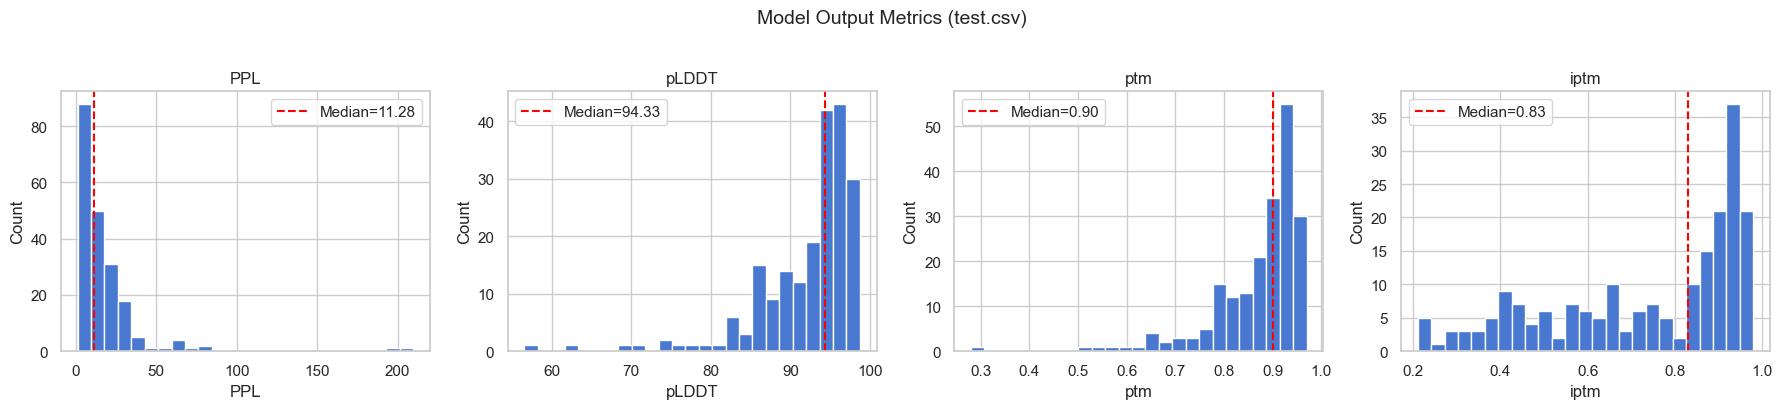

           PPL    pLDDT      ptm     iptm
count  203.000  203.000  203.000  203.000
mean    17.070   92.118    0.870    0.729
std     23.576    6.298    0.096    0.221
min      1.178   56.583    0.280    0.210
25%      4.485   89.552    0.840    0.553
50%     11.276   94.329    0.900    0.830
75%     21.141   96.110    0.931    0.920
max    209.670   98.710    0.970    0.980


In [6]:
metrics = ["PPL", "pLDDT", "ptm", "iptm"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, metrics):
    ax.hist(results_df[col].dropna(), bins=25, edgecolor="white")
    ax.axvline(results_df[col].median(), color="red", linestyle="--",
               label=f"Median={results_df[col].median():.2f}")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Model Output Metrics (test.csv)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(results_df[metrics].describe().round(3))

### 1.4 — PPL vs pLDDT: Do lower-perplexity binders fold better?

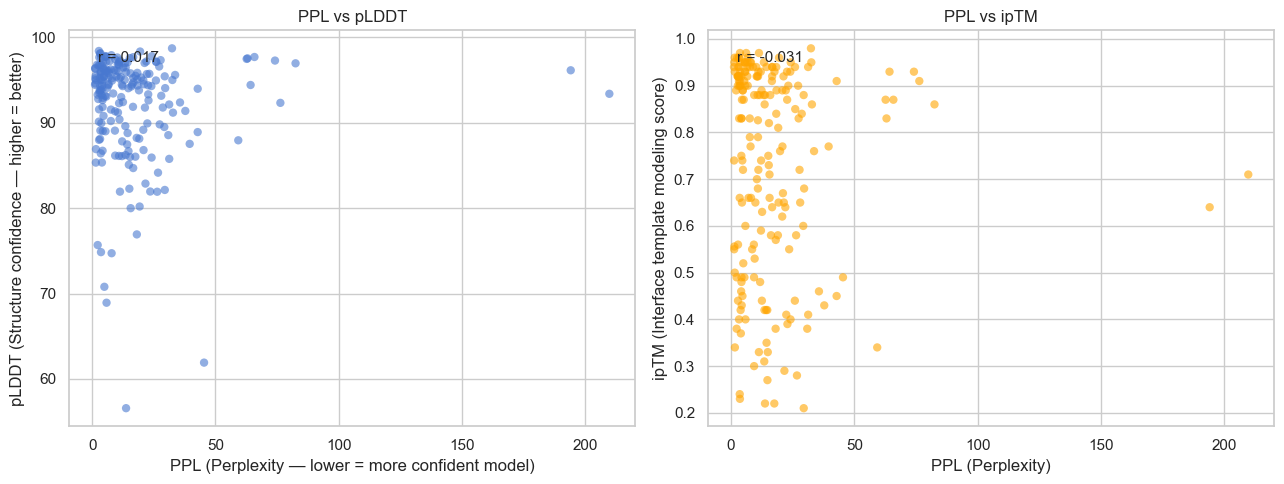

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(results_df["PPL"], results_df["pLDDT"], alpha=0.6, edgecolors="none")
axes[0].set_xlabel("PPL (Perplexity — lower = more confident model)")
axes[0].set_ylabel("pLDDT (Structure confidence — higher = better)")
axes[0].set_title("PPL vs pLDDT")
r = results_df[["PPL", "pLDDT"]].corr().iloc[0, 1]
axes[0].annotate(f"r = {r:.3f}", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=11)

axes[1].scatter(results_df["PPL"], results_df["iptm"], alpha=0.6, color="orange", edgecolors="none")
axes[1].set_xlabel("PPL (Perplexity)")
axes[1].set_ylabel("ipTM (Interface template modeling score)")
axes[1].set_title("PPL vs ipTM")
r2 = results_df[["PPL", "iptm"]].corr().iloc[0, 1]
axes[1].annotate(f"r = {r2:.3f}", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=11)

plt.tight_layout()
plt.show()

### 1.5 — Amino Acid Composition of Peptides

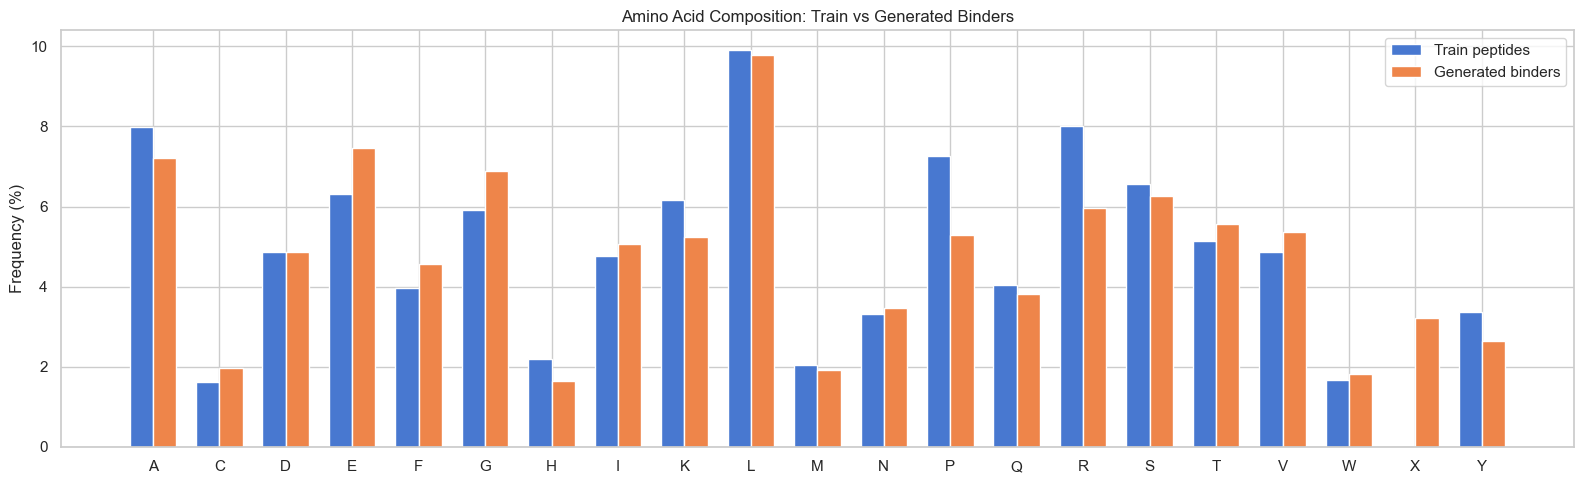

In [8]:
from collections import Counter

def aa_freq(sequences):
    counts = Counter("".join(sequences.dropna()))
    total = sum(counts.values())
    return {aa: counts[aa] / total * 100 for aa in sorted(counts)}

train_freq   = aa_freq(train_df["Sequence"])
results_freq = aa_freq(results_df["Binder"])

all_aa = sorted(set(train_freq) | set(results_freq))
x = np.arange(len(all_aa))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - width/2, [train_freq.get(a, 0) for a in all_aa], width, label="Train peptides")
ax.bar(x + width/2, [results_freq.get(a, 0) for a in all_aa], width, label="Generated binders")
ax.set_xticks(x)
ax.set_xticklabels(all_aa)
ax.set_ylabel("Frequency (%)")
ax.set_title("Amino Acid Composition: Train vs Generated Binders")
ax.legend()
plt.tight_layout()
plt.show()